Coincident Index (Dynamic Factor Model)
Based on the statsmodels example: 
https://www.statsmodels.org/dev/examples/notebooks/generated/statespace_dfm_coincident.html

In [5]:
# 1. Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas_datareader.data import DataReader
from statsmodels.tsa.statespace.dynamic_factor import DynamicFactor
import datetime
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import statsmodels.api as sm
import arviz as az
import pytensor.tensor as pt
import pymc as pm
import pytensor
from pymc_extras.statespace.core.statespace import PyMCStateSpace
from pymc_extras.statespace.utils.constants import (
    ALL_STATE_AUX_DIM,
    ALL_STATE_DIM
)
from pymc_extras.statespace.models.DFM import BayesianDynamicFactor

In [6]:
# 2. Download the data
# Series: INDPRO, PAYEMS, MANEMP, and RRSFS
# Monthly data from 1959-01 to 2020-12
start = datetime.datetime(1979, 1, 1)
end = datetime.datetime(2014, 12, 31)

In [24]:
indprod = DataReader("IPMAN", "fred", start=start, end=end)
income = DataReader("W875RX1", "fred", start=start, end=end)
sales = DataReader("CMRMTSPL", "fred", start=start, end=end)
emp = DataReader("PAYEMS", "fred", start=start, end=end)

In [25]:
data = pd.concat((indprod, income, sales, emp), axis=1)
data.columns = ["indprod", "income", "sales", "emp"]
data.index.freq = data.index.inferred_freq

In [26]:
print(data.head())

            indprod  income       sales    emp
DATE                                          
1979-01-01  47.1722  5248.7  561382.192  88808
1979-02-01  47.3093  5278.5  558729.039  89055
1979-03-01  47.5389  5294.3  574897.892  89479
1979-04-01  46.7402  5242.7  559387.521  89417
1979-05-01  47.3949  5227.5  571771.305  89789


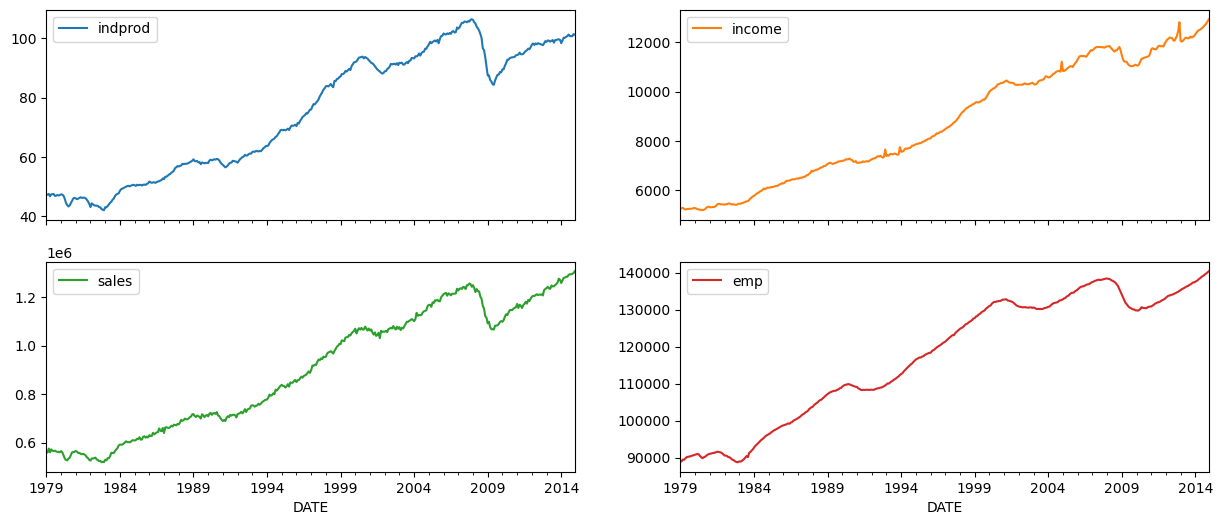

In [27]:
data.loc[:, "indprod":"emp"].plot(subplots=True, layout=(2, 2), figsize=(15, 6));

### Cointegration

In [8]:
def johansen_cointegration_test(df, det_order=-1, k_ar_diff=1):
    """
    Perform Johansen cointegration test
    det_order: Deterministic trend assumption (-1 to 3)
    k_ar_diff: Lag order for differencing (usually 1)
    """
    print("Johansen Cointegration Test Results")
    coint_test = coint_johansen(df.dropna(), det_order, k_ar_diff)

    trace_stat = coint_test.lr1
    crit_values = coint_test.cvt

    for i in range(len(trace_stat)):
        print(f"Rank {i}: Trace Statistic = {trace_stat[i]:.2f}, 90% CV = {crit_values[i, 0]:.2f}, 95% CV = {crit_values[i, 1]:.2f}, 99% CV = {crit_values[i, 2]:.2f}")
        if trace_stat[i] > crit_values[i, 1]:
            print("=> Reject H0: Cointegration rank >=", i)
        else:
            print("=> Fail to reject H0: Cointegration rank <", i)
        print()


In [9]:
coint_data = (data[['indprod', 'income', 'sales', 'emp']])
johansen_cointegration_test(coint_data)

Johansen Cointegration Test Results
Rank 0: Trace Statistic = 85.23, 90% CV = 37.03, 95% CV = 40.17, 99% CV = 46.57
=> Reject H0: Cointegration rank >= 0

Rank 1: Trace Statistic = 27.72, 90% CV = 21.78, 95% CV = 24.28, 99% CV = 29.51
=> Reject H0: Cointegration rank >= 1

Rank 2: Trace Statistic = 6.23, 90% CV = 10.47, 95% CV = 12.32, 99% CV = 16.36
=> Fail to reject H0: Cointegration rank < 2

Rank 3: Trace Statistic = 1.36, 90% CV = 2.98, 95% CV = 4.13, 99% CV = 6.94
=> Fail to reject H0: Cointegration rank < 3



The Johansen test indicates the presence of 2 cointegrating relationships among the 4 time series. This means there are 2 independent stationary linear combinations (cointegrating vectors). However, we will follow our reference, testing stationarity for each time series and eventually applying a tranformation.


### Stationarity

In [9]:
def adf_test(series, title=''):
    """
    Perform Augmented Dickey-Fuller test
    """
    print(f'ADF Test for {title}')
    result = adfuller(series.dropna(), autolag='AIC')
    labels = ['ADF Statistic', 'p-value', '# Observations']
    for value, label in zip(result[:4], labels):
        print(f"{label}: {value}")
    if result[1] <= 0.05:
        print("=> Stationary (reject H0)")
    else:
        print("=> Non-stationary (fail to reject H0)")
    print()


In [11]:

for col in ['indprod', 'income', 'sales', 'emp']:
    adf_test(data[col], title=col)
   

ADF Test for indprod
ADF Statistic: -0.6730347475672278
p-value: 0.8536110682655401
# Observations: 12
=> Non-stationary (fail to reject H0)

ADF Test for income
ADF Statistic: 0.0829843235392625
p-value: 0.9648799685690176
# Observations: 9
=> Non-stationary (fail to reject H0)

ADF Test for sales
ADF Statistic: -0.21492222758297064
p-value: 0.936719395568298
# Observations: 12
=> Non-stationary (fail to reject H0)

ADF Test for emp
ADF Statistic: -0.9032661691141197
p-value: 0.7868949183862891
# Observations: 3
=> Non-stationary (fail to reject H0)



In [28]:
# Create log-differenced series
data["dln_indprod"] = (np.log(data.indprod)).diff() * 100
data["dln_income"] = (np.log(data.income)).diff() * 100
data["dln_sales"] = (np.log(data.sales)).diff() * 100
data["dln_emp"] = (np.log(data.emp)).diff() * 100

# De-mean and standardize
data["std_indprod"] = (data["dln_indprod"] - data["dln_indprod"].mean()) / data[
    "dln_indprod"
].std()
data["std_income"] = (data["dln_income"] - data["dln_income"].mean()) / data[
    "dln_income"
].std()
data["std_sales"] = (data["dln_sales"] - data["dln_sales"].mean()) / data["dln_sales"].std()
data["std_emp"] = (data["dln_emp"] - data["dln_emp"].mean()) / data["dln_emp"].std()

In [29]:
# Get the endogenous data
endog = data.loc["1979-02-01":, "std_indprod":"std_emp"]

In [10]:
for col in ["std_indprod","std_income", "std_sales", "std_emp"]:
    adf_test(endog[col], title=col)

ADF Test for std_indprod
ADF Statistic: -7.3337173809532725
p-value: 1.1105668612348205e-10
# Observations: 2
=> Stationary (reject H0)

ADF Test for std_income
ADF Statistic: -4.455094080898953
p-value: 0.0002368322834477289
# Observations: 13
=> Stationary (reject H0)

ADF Test for std_sales
ADF Statistic: -8.827935086435593
p-value: 1.8022396062717108e-14
# Observations: 2
=> Stationary (reject H0)

ADF Test for std_emp
ADF Statistic: -4.175631871435514
p-value: 0.0007243551568346825
# Observations: 2
=> Stationary (reject H0)



As the reference notebook stated reporting the findings of the paper Stock and Watson (1991), we are able to reach stationarity after taking as transformation the first differences (of the logs).

In [30]:
print(endog.head())

            std_indprod  std_income  std_sales   std_emp
DATE                                                    
1979-02-01     0.144369    0.536870  -0.722874  0.897660
1979-03-01     0.392176    0.134841   2.867766  1.929842
1979-04-01    -2.391601   -1.787951  -3.163686 -0.918544
1979-05-01     1.550990   -0.751468   2.151995  1.616819
1979-06-01    -0.067774   -0.076092  -1.319191  1.300121


## Statsmodel

In [31]:
# 4. Fit the Dynamic Factor Model
mod = DynamicFactor(endog, k_factors=1, factor_order=2, error_order=2)
initial_res = mod.fit(method="powell", disp=False)
res = mod.fit(disp=False)
print(res.summary())

                                             Statespace Model Results                                            
Dep. Variable:     ['std_indprod', 'std_income', 'std_sales', 'std_emp']   No. Observations:                  431
Model:                                 DynamicFactor(factors=1, order=2)   Log Likelihood               -2050.756
                                                          + AR(2) errors   AIC                           4137.513
Date:                                                   Mon, 14 Jul 2025   BIC                           4210.703
Time:                                                           12:19:28   HQIC                          4166.410
Sample:                                                       02-01-1979                                         
                                                            - 12-01-2014                                         
Covariance Type:                                                     opg                

/opt/anaconda3/envs/pymc_extras_env/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


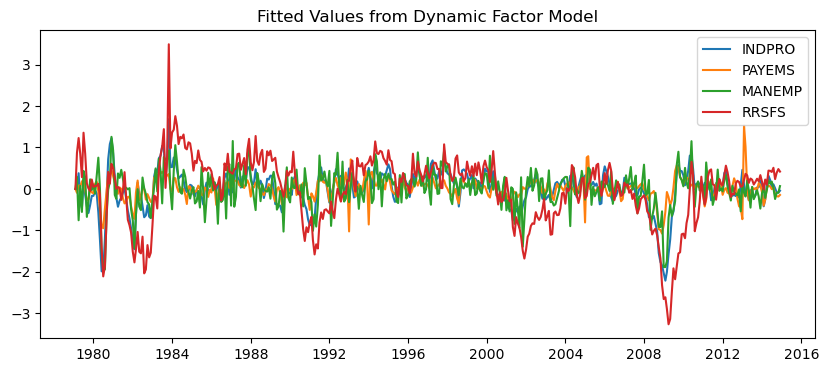

In [32]:
# 5. Plot the estimated factor
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(res.fittedvalues.index, res.fittedvalues.iloc[:, 0], label='INDPRO')
ax.plot(res.fittedvalues.index, res.fittedvalues.iloc[:, 1], label='PAYEMS')
ax.plot(res.fittedvalues.index, res.fittedvalues.iloc[:, 2], label='MANEMP')
ax.plot(res.fittedvalues.index, res.fittedvalues.iloc[:, 3], label='RRSFS')
ax.legend()
ax.set(title='Fitted Values from Dynamic Factor Model')
plt.show()

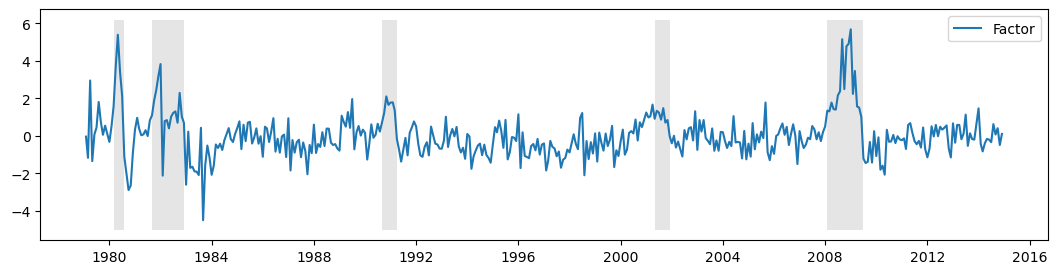

In [18]:
fig, ax = plt.subplots(figsize=(13, 3))

# Plot the factor
dates = endog.index._mpl_repr()
ax.plot(dates, res.factors.filtered[0], label="Factor")
ax.legend()

# Retrieve and also plot the NBER recession indicators
rec = DataReader("USREC", "fred", start=start, end=end)
ylim = ax.get_ylim()
ax.fill_between(
    dates[:-3], ylim[0], ylim[1], rec.values[:-4, 0], facecolor="k", alpha=0.1
);

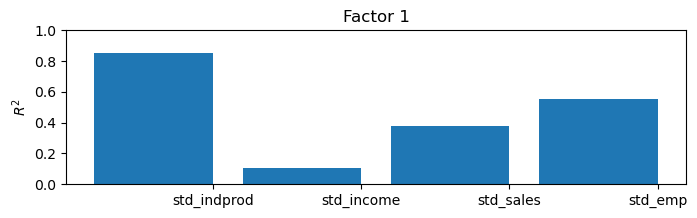

In [19]:
res.plot_coefficients_of_determination(figsize=(8, 2));

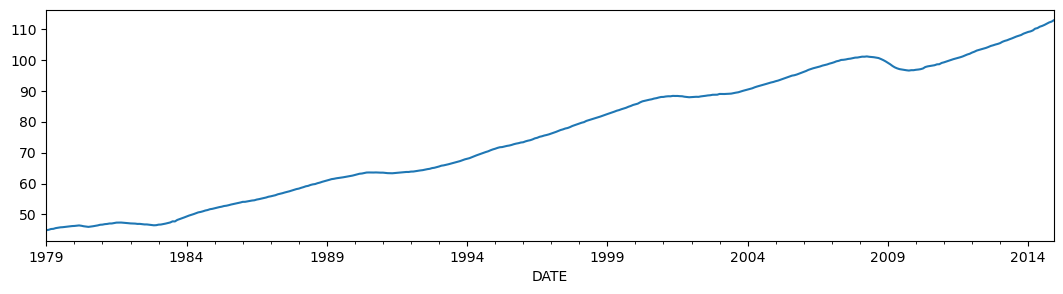

In [20]:
usphci = DataReader("USPHCI", "fred", start=start, end=end)["USPHCI"]
usphci.plot(figsize=(13, 3));

In [21]:
dusphci = usphci.diff()[1:].values

def compute_coincident_index(mod, res):
    # Estimate W(1)
    spec = res.specification
    design = mod.ssm["design"]
    transition = mod.ssm["transition"]
    ss_kalman_gain = res.filter_results.kalman_gain[:, :, -1]

    k_states = ss_kalman_gain.shape[0]

    W1 = np.linalg.inv(
        np.eye(k_states)
        - np.dot(np.eye(k_states) - np.dot(ss_kalman_gain, design), transition)
    ).dot(ss_kalman_gain)[0]

    # Compute the factor mean vector
    factor_mean = np.dot(W1, data.loc[start:, "dln_indprod":"dln_emp"].mean())

    # Normalize the factors
    factor = res.factors.filtered[0].copy()

    factor *= np.std(usphci.diff()[1:]) / np.std(factor)

    # Compute the coincident index
    coincident_index = np.zeros(mod.nobs + 1)
    # The initial value is arbitrary; here it is set to
    # facilitate comparison
    coincident_index[0] = usphci.iloc[0] * factor_mean / dusphci.mean()
    for t in range(0, mod.nobs):
        coincident_index[t + 1] = coincident_index[t] + factor[t] + factor_mean

    # Attach dates
    coincident_index = pd.Series(coincident_index, index=data.index).iloc[1:]

    # Normalize to use the same base year as USPHCI
    coincident_index *= usphci.loc["1992-07-01"] / coincident_index.loc["1992-07-01"]

    return coincident_index, factor

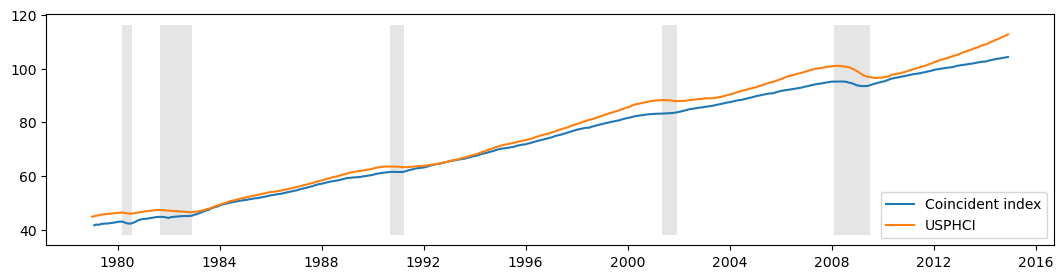

In [22]:
fig, ax = plt.subplots(figsize=(13, 3))

# Compute the index
coincident_index_res, factor_res = compute_coincident_index(mod, res)

# Plot the factor
dates = endog.index._mpl_repr()
ax.plot(dates, coincident_index_res, label="Coincident index")
ax.plot(usphci.index._mpl_repr(), usphci, label="USPHCI")
ax.legend(loc="lower right")

# Retrieve and also plot the NBER recession indicators
ylim = ax.get_ylim()
ax.fill_between(
    dates[:-3], ylim[0], ylim[1], rec.values[:-4, 0], facecolor="k", alpha=0.1
);

## PyMC

In [33]:
matrix_names = [
    "initial_state",
    "initial_state_cov",
    "state_intercept",
    "obs_intercept",
    "transition",
    "design",
    "selection",
    "obs_cov",
    "state_cov",
]


def print_model_ssm(mod, how="eval"):
    nice_heading = f'{"name":<20}{"__repr__":<50}{"shape":<10}{"value":<20}'
    print(nice_heading)
    print("=" * len(nice_heading))
    if how == "eval":
        matrices = [x.eval() for x in mod._unpack_statespace_with_placeholders()]
    elif how == "draw":
        matrices = pm.draw(mod.unpack_statespace())

    for name, value in zip(matrix_names, matrices):
        repr_ = str(mod.ssm[name])
        shape = str(mod.ssm[name].type.shape)
        value = str(value).replace("\n ", "\n" + " " * 81)
        print(f"{name:<20}{repr_:<50}{shape:<10}{value:<20}")
        print("-" * len(nice_heading))

### PyMC Custom

In [26]:
class DFM_dummy(PyMCStateSpace):
    def __init__(self, mode=None):
        k_states = 10  # 2 for factor + 2*4 for error terms
        k_posdef = 5   # 1 for factor shock + 4 for individual AR error shocks
        k_endog = 4    # 4 observed time series

        super().__init__(k_endog=k_endog, k_states=k_states, k_posdef=k_posdef)

    def make_symbolic_graph(self):
        x0 = self.make_and_register_variable("x0", shape=(10,))
        P0 = self.make_and_register_variable("P0", shape=(10, 10))

        lambdas = self.make_and_register_variable("lambdas", shape=(4,))

        ar = self.make_and_register_variable("ar", shape=(2,))
        sigma_f = self.make_and_register_variable("sigma_f", shape=())

        c = self.make_and_register_variable("c", shape=(4, 2))
        sigmas = self.make_and_register_variable("sigmas", shape=(4,))

        # Design matrix Z
        self.ssm["design", :, :] = 0.0
        for i in range(4):
            self.ssm["design", i, 0] = lambdas[i]
            self.ssm["design", i, 2*i+2] = 1.0

        # Transition matrix T
        self.ssm["transition", :, :] = 0.0
        self.ssm["transition", 0, 0] = ar[0]
        self.ssm["transition", 0, 1] = ar[1]
        self.ssm["transition", 1, 0] = 1.0

        for i in range(4):
            pos = 2*i + 2
            self.ssm["transition", pos, pos] = c[i, 0]
            self.ssm["transition", pos, pos+1] = c[i, 1]
            self.ssm["transition", pos+1, pos] = 1.0

        # Selection matrix R
        self.ssm["selection", :, :] = 0.0
        self.ssm["selection", 0, 0] = 1.0
        for i in range(4):
            self.ssm["selection", 2*i+2, i+1] = 1.0

        # State covariance matrix Q
        self.ssm["state_cov", :, :] = 0.0
        self.ssm["state_cov", 0, 0] = sigma_f
        for i in range(4):
            self.ssm["state_cov", i+1, i+1] = sigmas[i]

        # Observation covariance matrix H
        self.ssm["obs_cov", :, :] = pt.zeros((4, 4))

        # Initial conditions
        self.ssm["initial_state", :] = x0
        self.ssm["initial_state_cov", :, :] = P0

    @property
    def param_names(self):
        names = ["x0", "P0", "ar", "sigma_f", "lambdas", "c", "sigmas"]
        return names

    @property
    def state_names(self):
        names = ["f_1", "f_2"]
        for i in range(4):
            names.extend([f"u{i+1}_1", f"u{i+1}_2"])
        return names

    @property
    def shock_names(self):
        return ["f_noise"] + [f"u{i+1}_noise" for i in range(4)]

    @property
    def observed_states(self):
        return ["std_indprod", "std_income", "std_sales", "std_emp"]

    @property
    def param_dims(self):
        dims = {
            "x0": (ALL_STATE_DIM,),
            "P0": (ALL_STATE_DIM, ALL_STATE_AUX_DIM),
            "ar": ("ar_order"),
            "sigma_f": (),
            "lambdas": ("obs_dim",),
            "c": ("obs_dim", "ar_order"),
            "sigmas": ("obs_dim",),
        }
        return dims

    @property
    def coords(self):
        coords = {
            "time": np.arange(endog.shape[0]),
            "obs_dim": [f"y{i+1}" for i in range(4)],
            "ar_order": ["phi1", "phi2"],
            "state_dim": self.state_names,
            "shock_dim": self.shock_names,
            "ALL_STATE_DIM": list(range(self.k_states)),
            "ALL_STATE_AUX_DIM": list(range(self.k_states)),
        }
        return coords

    @property
    def param_info(self):
        info = {
            "x0": {"shape": (self.k_states,), "constraints": "None"},
            "P0": {"shape": (self.k_states, self.k_states), "constraints": "Positive Semi-definite"},
            "ar": {"shape": (2,), "constraints": "None"},         
            "sigma_f": {"shape": (), "constraints": "Positive"},
            "lambdas": {"shape": (4,), "constraints": "None"},
            "c": {"shape": (4, 2), "constraints": "None"},
            "sigmas": {"shape": (4,), "constraints": "Positive"},
        }

        for name in self.param_names:
            info[name]["dims"] = self.param_dims[name]

        return info



Using as mean of prior distribution for the parameters the result of the stats model

In [27]:
dfm_dummy = DFM_dummy()
params = res.params.to_dict()

with pm.Model() as pymc_mod:

    #y_obs = pm.Data("y_obs", endog, dims=("time", "obs_dim"))
    # Initial state
    x0 = pm.Deterministic("x0", pt.zeros(10))
    P0 = pm.Deterministic("P0", pt.eye(10))

    # Factor loadings vector
    lambda_vals = [
        params['loading.f1.std_indprod'],
        params['loading.f1.std_income'],
        params['loading.f1.std_sales'],
        params['loading.f1.std_emp']
    ]
    lambdas = pm.Normal("lambdas", mu=pt.constant(lambda_vals), sigma=0.2, shape=4)

    # AR(2) coefficients for factor f_t
    ar_vals = [
        params['L1.f1.f1'],
        params['L2.f1.f1']
    ]
    ar = pm.Normal("ar", mu=pt.constant(ar_vals), sigma=0.1, shape=(2,))

    # Fixed factor standard deviation
    sigma_f = pm.Deterministic("sigma_f", pt.constant(1.0, dtype=float))

    # AR(2) coefficients for idiosyncratic components as matrix cs: shape (4, 2)
    c_mu = [
        [params['L1.e(std_indprod).e(std_indprod)'], params['L2.e(std_indprod).e(std_indprod)']],
        [params['L1.e(std_income).e(std_income)'], params['L2.e(std_income).e(std_income)']],
        [params['L1.e(std_sales).e(std_sales)'], params['L2.e(std_sales).e(std_sales)']],
        [params['L1.e(std_emp).e(std_emp)'], params['L2.e(std_emp).e(std_emp)']]
    ]
    cs = pm.Normal("c", mu=pt.constant(c_mu), sigma=0.1, shape=(4, 2))

    # Standard deviations for idiosyncratic shocks
    sigma_vals = [
        params['sigma2.std_indprod'],
        params['sigma2.std_income'],
        params['sigma2.std_sales'],
        params['sigma2.std_emp']
    ]
    sigmas = pm.HalfNormal("sigmas", sigma=pt.constant(sigma_vals), shape=4)

    # Build symbolic graph
    dfm_dummy.build_statespace_graph(data=endog, mode="JAX")


                            Model Requirements                            
                                                                          
  Variable   Shape      Constraints                           Dimensions  
 ──────────────────────────────────────────────────────────────────────── 
  x0         (10,)      None                                  ('state',)  
  P0         (10, 10)   Positive Semi-definite    ('state', 'state_aux')  
  ar         (2,)       None                                    ar_order  
  sigma_f    ()         Positive                                      ()  
  lambdas    (4,)       None                                ('obs_dim',)  
  c          (4, 2)     None                     ('obs_dim', 'ar_order')  
  sigmas     (4,)       Positive                            ('obs_dim',)  
                                                                          
   These parameters should be assigned priors inside a PyMC model block   
            before calling the build_statespace_graph method.             

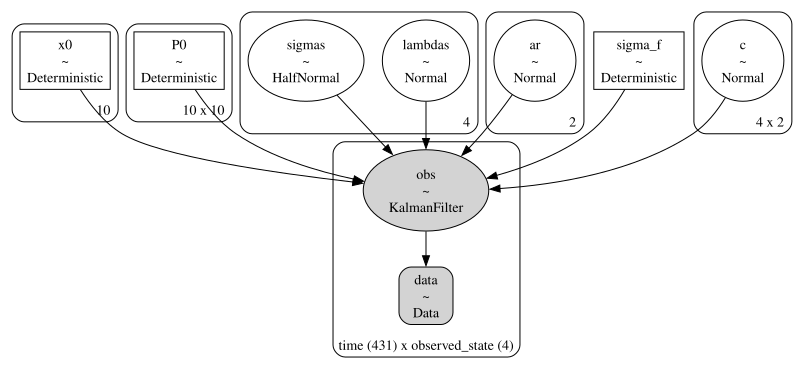

In [28]:
pymc_mod.to_graphviz()

In [29]:
print_model_ssm(dfm_dummy, "draw")

name                __repr__                                          shape     value               
initial_state       initial_state                                     (10,)     [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
----------------------------------------------------------------------------------------------------
initial_state_cov   initial_state_cov                                 (10, 10)  [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
                                                                                 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
                                                                                 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
                                                                                 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
                                                                                 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
                                                                                 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
        

In [ ]:
with pymc_mod:
    idata = pm.sample(
    draws=500,
    chains=2,
    nuts_sampler="nutpie",
    nuts_sampler_kwargs={"backend": "jax", "gradient_backend": "jax"},
)
    # idata= pmx.fit_laplace(compile_kwargs={'mode':'JAX'} ,
    #                         gradient_backend='jax')
    


idata.to_netcdf("NutpieResPrior3.nc")

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.63,7
,1500,0,0.66,7


'NutpieResPrior3.nc'

In [31]:
idata_custom = az.from_netcdf("Results/NutpieResPrior3.nc")

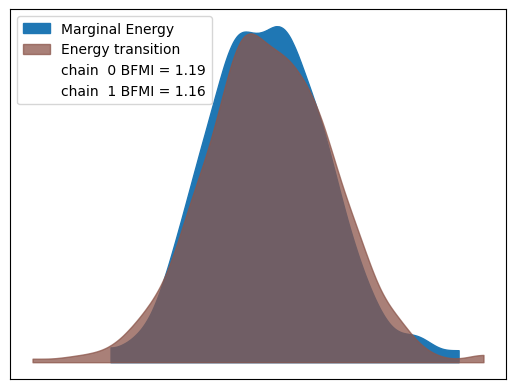

In [32]:
az.plot_energy(idata_custom);

In [59]:
var_names_list_custom = [name for name in dfm_dummy.param_names if name not in {"x0", "P0", "sigma_f"}]

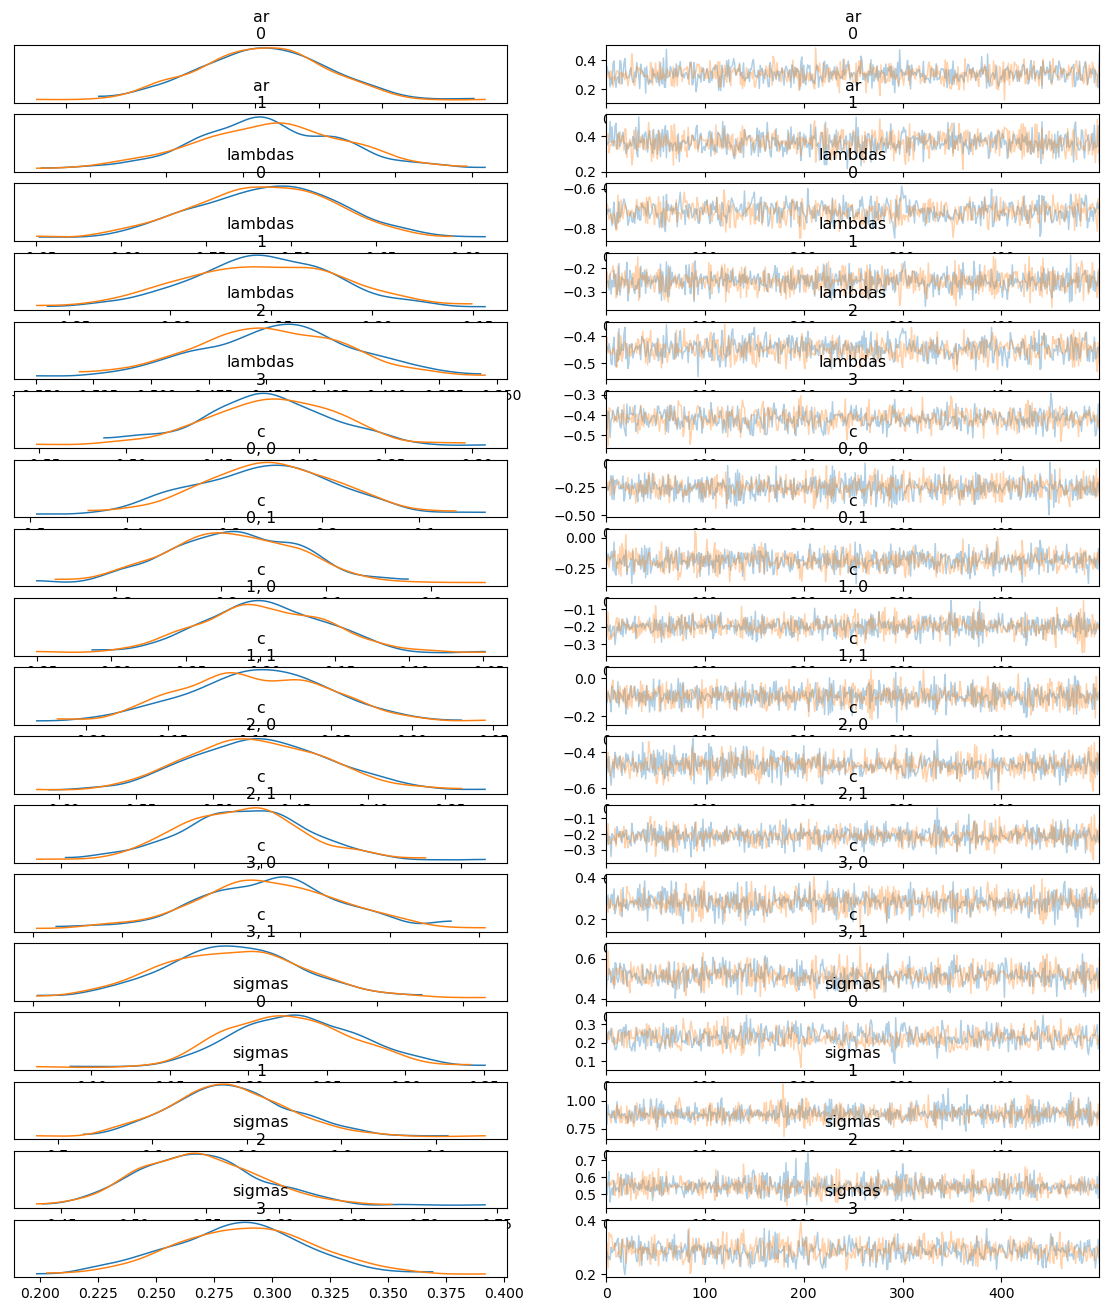

In [60]:
az.plot_trace(
    idata_custom,
    var_names=var_names_list_custom,
    figsize=(14, 16),
    compact=False
);

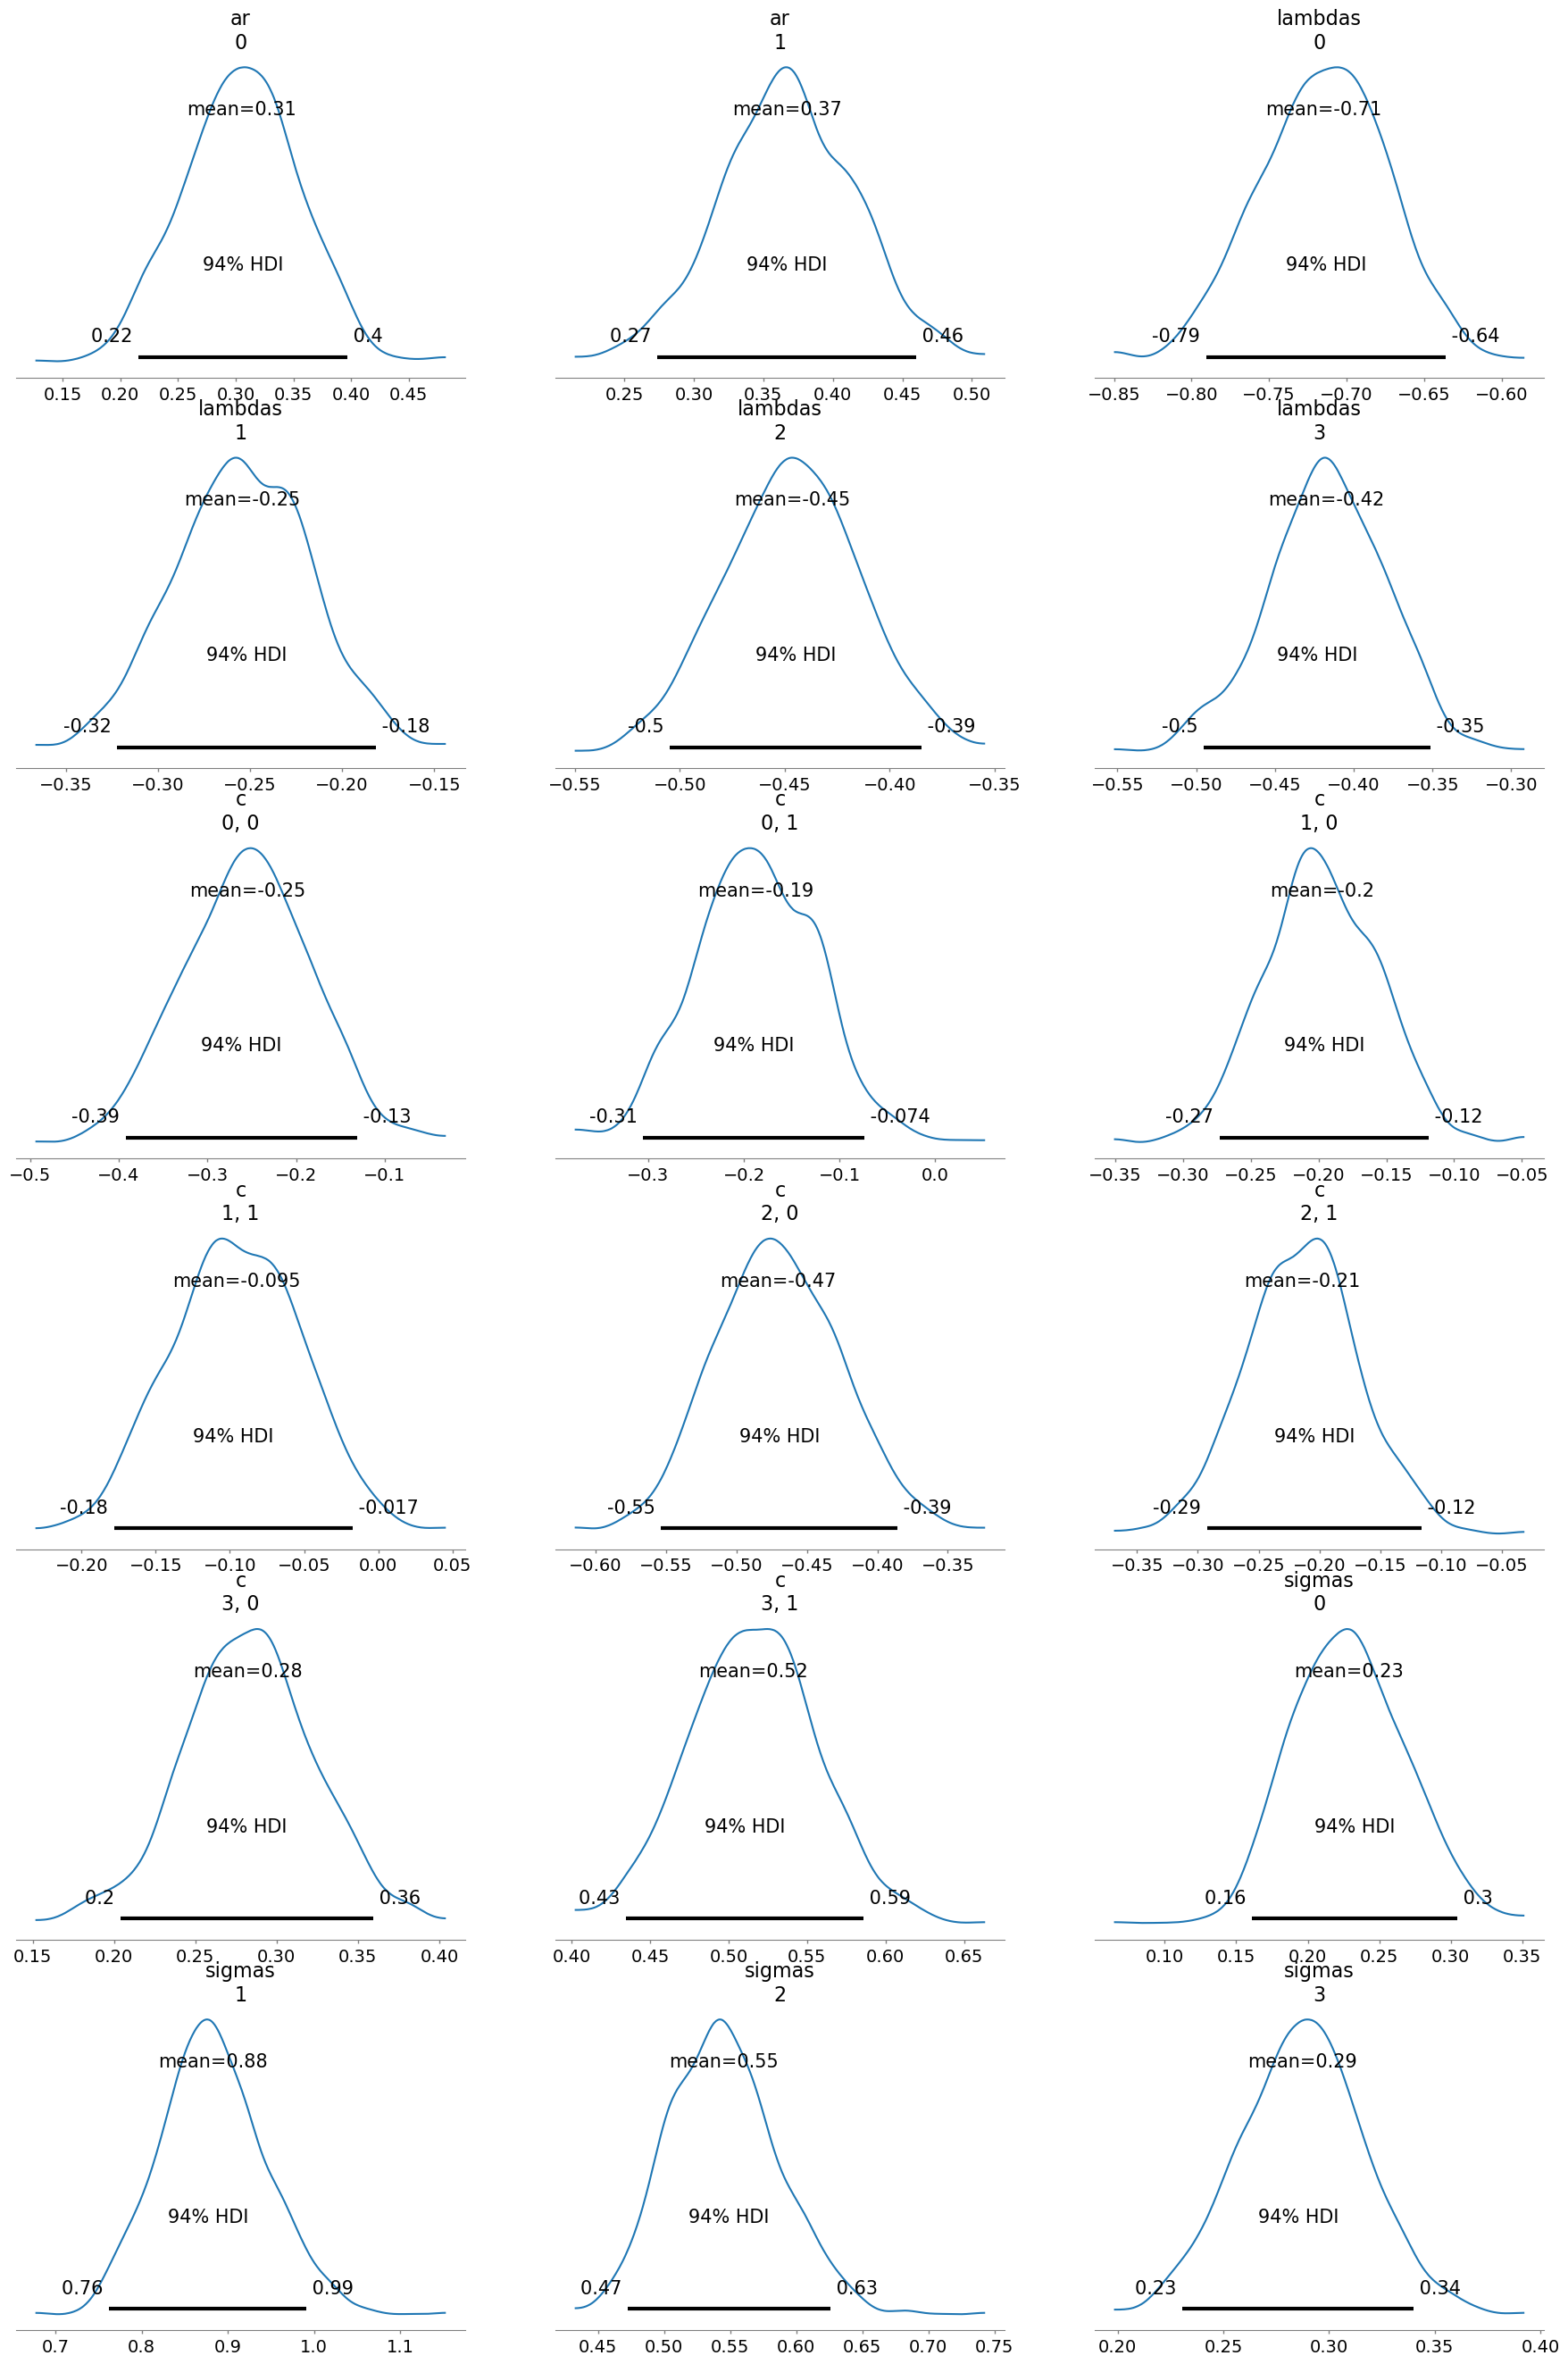

In [61]:
az.plot_posterior(
    idata_custom,
    var_names=var_names_list_custom
);

In [36]:
with pm.Model() as index_mod:
    dfm_dummy._build_dummy_graph()
    dfm_dummy._insert_random_variables()
    x0, P0, C, D, T, Z, R, H, Q = matrices = dfm_dummy.unpack_statespace()

    dfm_dummy.build_statespace_graph(data=endog, mode="JAX", save_kalman_filter_outputs_in_idata=True)
    predicted_covariance = index_mod["predicted_covariance"]
    filtered_state = index_mod["filtered_state"]

    def step(P, Z, T, H):
        PZT = pt.dot(P, Z.T)
        F = Z.dot(PZT) + H + pt.eye(H.shape[0]) * 1e-6

        # K = pt.linalg.solve(F, pt.dot(T, PZT).T, assume_a="pos", check_finite=False).T   
        K = pt.linalg.solve(F, PZT.T, assume_a="pos", check_finite=False).T
        return K

    ss_kalman_gain, updates = pytensor.scan(step, non_sequences=[Z, T, H], 
                                           sequences=[predicted_covariance])
    
    ss_kalman_gain = ss_kalman_gain[-1] # Get the last Kalman gain (steady state)

    k_states = T.shape[0]
    W1 = pt.linalg.inv(
        pt.eye(k_states)
        - pt.dot(pt.eye(k_states) - pt.dot(ss_kalman_gain, Z), T)
    ).dot(ss_kalman_gain)[0]

    # Compute the factor mean vector
    factor_mean = pt.dot(W1, data.loc[start:, "dln_indprod":"dln_emp"].mean())

    state_0 = filtered_state[..., 0]

    # Normalization
    normalizer = np.std(usphci.diff()[1:]) / pt.std(state_0)
    state_0_scaled = state_0 * normalizer

    # Initial value (scalar)
    initial_value = usphci.iloc[0] * factor_mean / dusphci.mean()

    # Increments: each increment is state[t] + factor_mean (broadcasted)
    increments = state_0_scaled + factor_mean  # shape: (T,)

    # Cumulative sum of increments
    cumsum_increments = pt.cumsum(increments)
    coincident_index = pt.concatenate([[initial_value], initial_value + cumsum_increments])

    # Normalize to match USPHCI base year (e.g., July 1992)
    ref_idx = list(data.index).index(pd.Timestamp("1992-07-01"))
    base_value = usphci.loc["1992-07-01"]
    normalization_factor = base_value / coincident_index[ref_idx]
    coincident_index = coincident_index * normalization_factor

    pm.Deterministic("factor_mean", factor_mean)

    factor_mean_idata_custom = pm.sample_posterior_predictive(idata_custom, var_names=["factor_mean"])
    filtered_state_idata_custom = pm.sample_posterior_predictive(idata_custom, var_names=["filtered_state"])

    pm.Deterministic("coincident_index", coincident_index)
    coincident_index_idata_custom = pm.sample_posterior_predictive(idata_custom, var_names=["coincident_index"])


Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

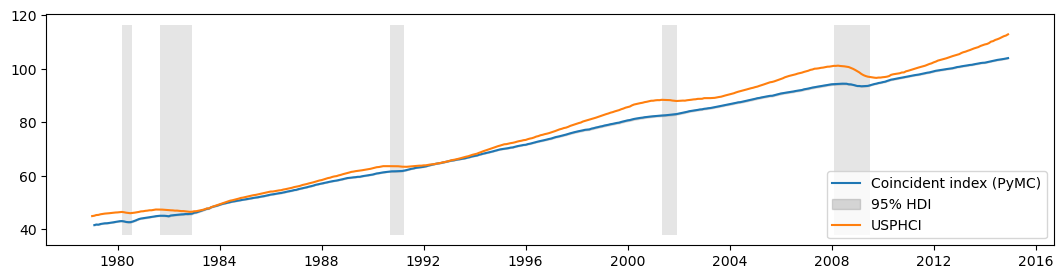

In [37]:
fig, ax = plt.subplots(figsize=(13, 3))

# Compute the index
coincident_index_pymc_samples_custom = coincident_index_idata_custom.posterior_predictive["coincident_index"].values
coincident_index_pymc_custom = coincident_index_pymc_samples_custom.mean(axis=(0, 1))


hdi_index_custom = az.hdi(coincident_index_pymc_samples_custom, hdi_prob=0.95)  
lower_index_custom, upper_index_custom = hdi_index_custom[..., 0], hdi_index_custom[..., 1]    

# Plot the factor
dates = endog.index._mpl_repr()
ax.plot(dates, coincident_index_pymc_custom[1:], label="Coincident index (PyMC)")
ax.fill_between(dates, lower_index_custom[1:], upper_index_custom[1:], color='gray', alpha=0.3, label="95% HDI")
ax.plot(usphci.index._mpl_repr(), usphci, label="USPHCI")
ax.legend(loc="lower right")

# Retrieve and also plot the NBER recession indicators
ylim = ax.get_ylim()
ax.fill_between(
    dates[:-3], ylim[0], ylim[1], rec.values[:-4, 0], facecolor="k", alpha=0.1
);

In [38]:
# Extract posterior predictive samples
state_samples_custom = filtered_state_idata_custom.posterior_predictive["filtered_state"].values  # shape: (2, 500, 10, 431)

# Select the first state (index 0)
state_0_samples_custom = state_samples_custom[:, :, :, 0]  # shape: (1, 1000, 431)

# Average over chains and draws to get posterior mean for each time point
state_0_mean_custom = state_0_samples_custom.mean(axis=(0, 1))  # shape: (431,)

# Get the time index from your observed data for x-axis
dates = filtered_state_idata_custom.observed_data.time.values  # array of datetime64


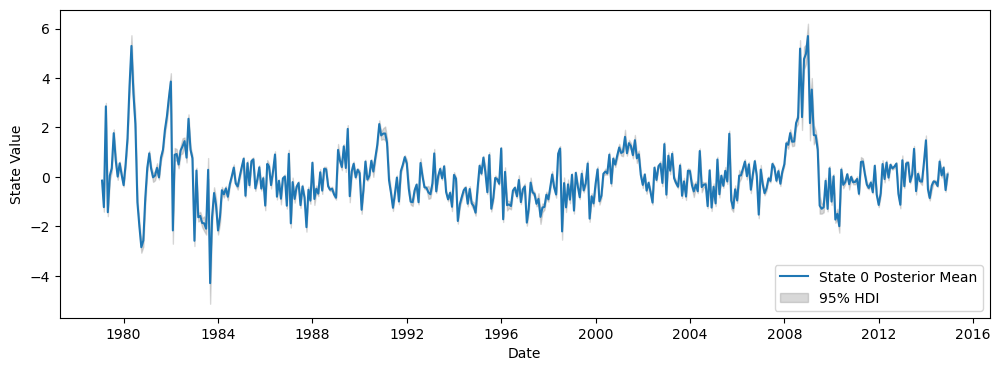

In [39]:
hdi_state_custom = az.hdi(state_0_samples_custom, hdi_prob=0.95)  
lower_state_custom, upper_state_custom = hdi_state_custom[..., 0], hdi_state_custom[..., 1]    

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dates, state_0_mean_custom, label="State 0 Posterior Mean")
ax.fill_between(dates, lower_state_custom, upper_state_custom, color='gray', alpha=0.3, label="95% HDI")
ax.set_xlabel("Date")
ax.set_ylabel("State Value")
ax.legend()
plt.show()

### PyMC using DFM.py

In [34]:
# Initialize the model
dfm = BayesianDynamicFactor(
    k_endog=4,
    k_factors=1,
    factor_order=2,
    error_order=2,
    error_var=False,
    error_cov_type="diagonal",
    filter_type="standard",
    verbose=True,
)

                                      Model Requirements                                      
                                                                                              
  Variable          Shape      Constraints                                        Dimensions  
 ──────────────────────────────────────────────────────────────────────────────────────────── 
  x0                (10,)                                                         ('state',)  
  P0                (10, 10)   Positive Semi-definite                 ('state', 'state_aux')  
  factor_loadings   (4, 1)                                      ('observed_state', 'factor')  
  factor_ar         (1, 2)                                              ('factor', 'ar_lag')  
  factor_sigma      (1,)       Positive                                          ('factor',)  
  error_ar          (4, 2)                              ('observed_state', 'error_ar_param')  
  error_sigma       (4,)       Positive                                  ('observed_state',)  
                                                                                              
   These parameters should be assigned priors inside a PyMC model block before calling the    
                                build_statespace_graph method.                                

In [35]:
params = res.params.to_dict()

with pm.Model() as pymc_mod:

    # Initial state
    x0 = pm.Deterministic("x0", pt.zeros(10))
    P0 = pm.Deterministic("P0", pt.eye(10))

    # Factor loadings vector
    lambda_vals = [
        params['loading.f1.std_indprod'],
        params['loading.f1.std_income'],
        params['loading.f1.std_sales'],
        params['loading.f1.std_emp']
    ]
    facttor_loadings = pm.Normal("factor_loadings", mu=pt.constant(lambda_vals).reshape((4,1)), sigma=0.2, shape=(4,1))
    #facttor_loadings = pm.Normal("factor_loadings", sigma=0.2, shape=(4,1))

    # AR(2) coefficients for factor f_t
    ar_vals = [
        params['L1.f1.f1'],
        params['L2.f1.f1']
    ]
    factor_ar = pm.Normal("factor_ar", mu=pt.constant(ar_vals), sigma=0.1, shape=(1,2))

    # Fixed factor standard deviation
    factor_sigma = pm.Deterministic("factor_sigma", pt.constant([1.0], dtype=float))

    # AR(2) coefficients for idiosyncratic components as matrix error_ar_mu: shape (4, 2)
    error_ar_mu = [
        [params['L1.e(std_indprod).e(std_indprod)'], params['L2.e(std_indprod).e(std_indprod)']],
        [params['L1.e(std_income).e(std_income)'], params['L2.e(std_income).e(std_income)']],
        [params['L1.e(std_sales).e(std_sales)'], params['L2.e(std_sales).e(std_sales)']],
        [params['L1.e(std_emp).e(std_emp)'], params['L2.e(std_emp).e(std_emp)']]
    ]
    error_ar = pm.Normal("error_ar", mu=pt.constant(error_ar_mu), sigma=0.1, shape=(4, 2))

    # Standard deviations for idiosyncratic shocks
    error_sigma_vals = [
        params['sigma2.std_indprod'],
        params['sigma2.std_income'],
        params['sigma2.std_sales'],
        params['sigma2.std_emp']
    ]
    sigmas = pm.HalfNormal("error_sigma", sigma=pt.constant(error_sigma_vals), shape=(4))

    # Build symbolic graph
    dfm.build_statespace_graph(data=endog, mode="JAX")

In [36]:
print_model_ssm(dfm, "draw")

name                __repr__                                          shape     value               
initial_state       initial_state                                     (10,)     [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
----------------------------------------------------------------------------------------------------
initial_state_cov   initial_state_cov                                 (10, 10)  [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
                                                                                 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
                                                                                 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
                                                                                 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
                                                                                 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
                                                                                 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
        

In [85]:
with pymc_mod:
    idata = pm.sample(
    draws=500,
    chains=2,
    nuts_sampler="nutpie",
    nuts_sampler_kwargs={"backend": "jax", "gradient_backend": "jax"},
)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.66,7
,1500,0,0.62,7


In [44]:
idata_dfm_py = az.from_netcdf("Results/NutpieResPriorDFM_py.nc")

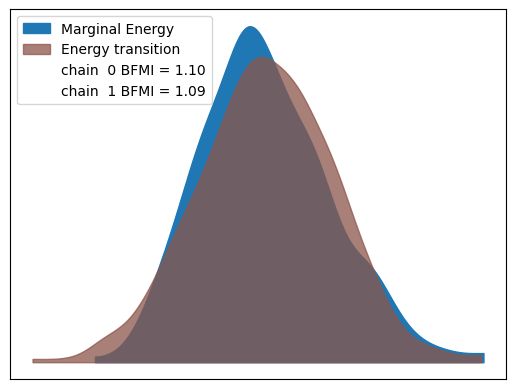

In [45]:
az.plot_energy(idata_dfm_py);

In [55]:
var_names_list_dfm_py = [name for name in dfm.param_names if name not in {"x0", "P0", "factor_sigma"}]

In [56]:
az.summary(idata_dfm_py, var_names=var_names_list_dfm_py)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"factor_loadings[0, 0]",-0.711,0.043,-0.786,-0.628,0.002,0.001,811.0,596.0,1.00
"factor_loadings[1, 0]",-0.253,0.037,-0.319,-0.186,0.001,0.002,3000.0,724.0,1.01
"factor_loadings[2, 0]",-0.446,0.033,-0.509,-0.384,0.001,0.001,1004.0,663.0,1.00
"factor_loadings[3, 0]",-0.419,0.040,-0.491,-0.348,0.001,0.001,907.0,526.0,1.00
"factor_ar[0, 0]",0.307,0.052,0.213,0.401,0.001,0.001,1229.0,734.0,1.00
"factor_ar[0, 1]",0.366,0.050,0.267,0.453,0.001,0.001,1353.0,901.0,1.00
"error_ar[0, 0]",-0.253,0.072,-0.379,-0.113,0.002,0.002,1825.0,913.0,1.00
"error_ar[0, 1]",-0.183,0.064,-0.305,-0.066,0.002,0.002,1493.0,792.0,1.00
"error_ar[1, 0]",-0.197,0.043,-0.279,-0.118,0.001,0.001,1919.0,746.0,1.00
"error_ar[1, 1]",-0.096,0.045,-0.184,-0.020,0.001,0.002,2168.0,657.0,1.01


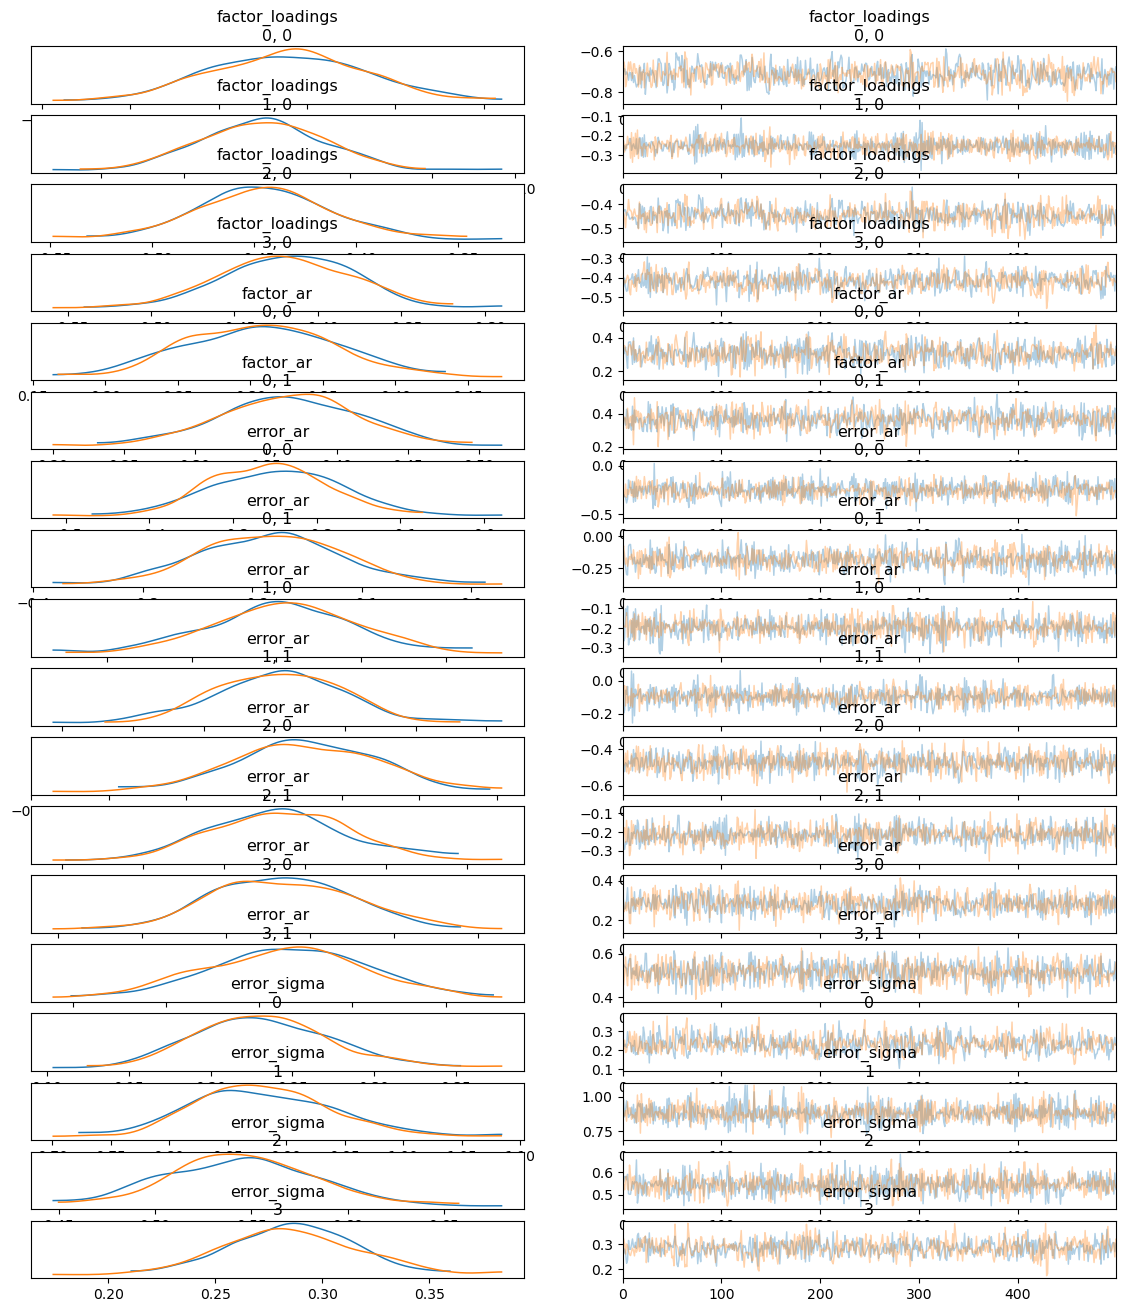

In [57]:
az.plot_trace(
    idata_dfm_py,
    var_names=var_names_list_dfm_py,
    figsize=(14, 16),
    compact=False
);

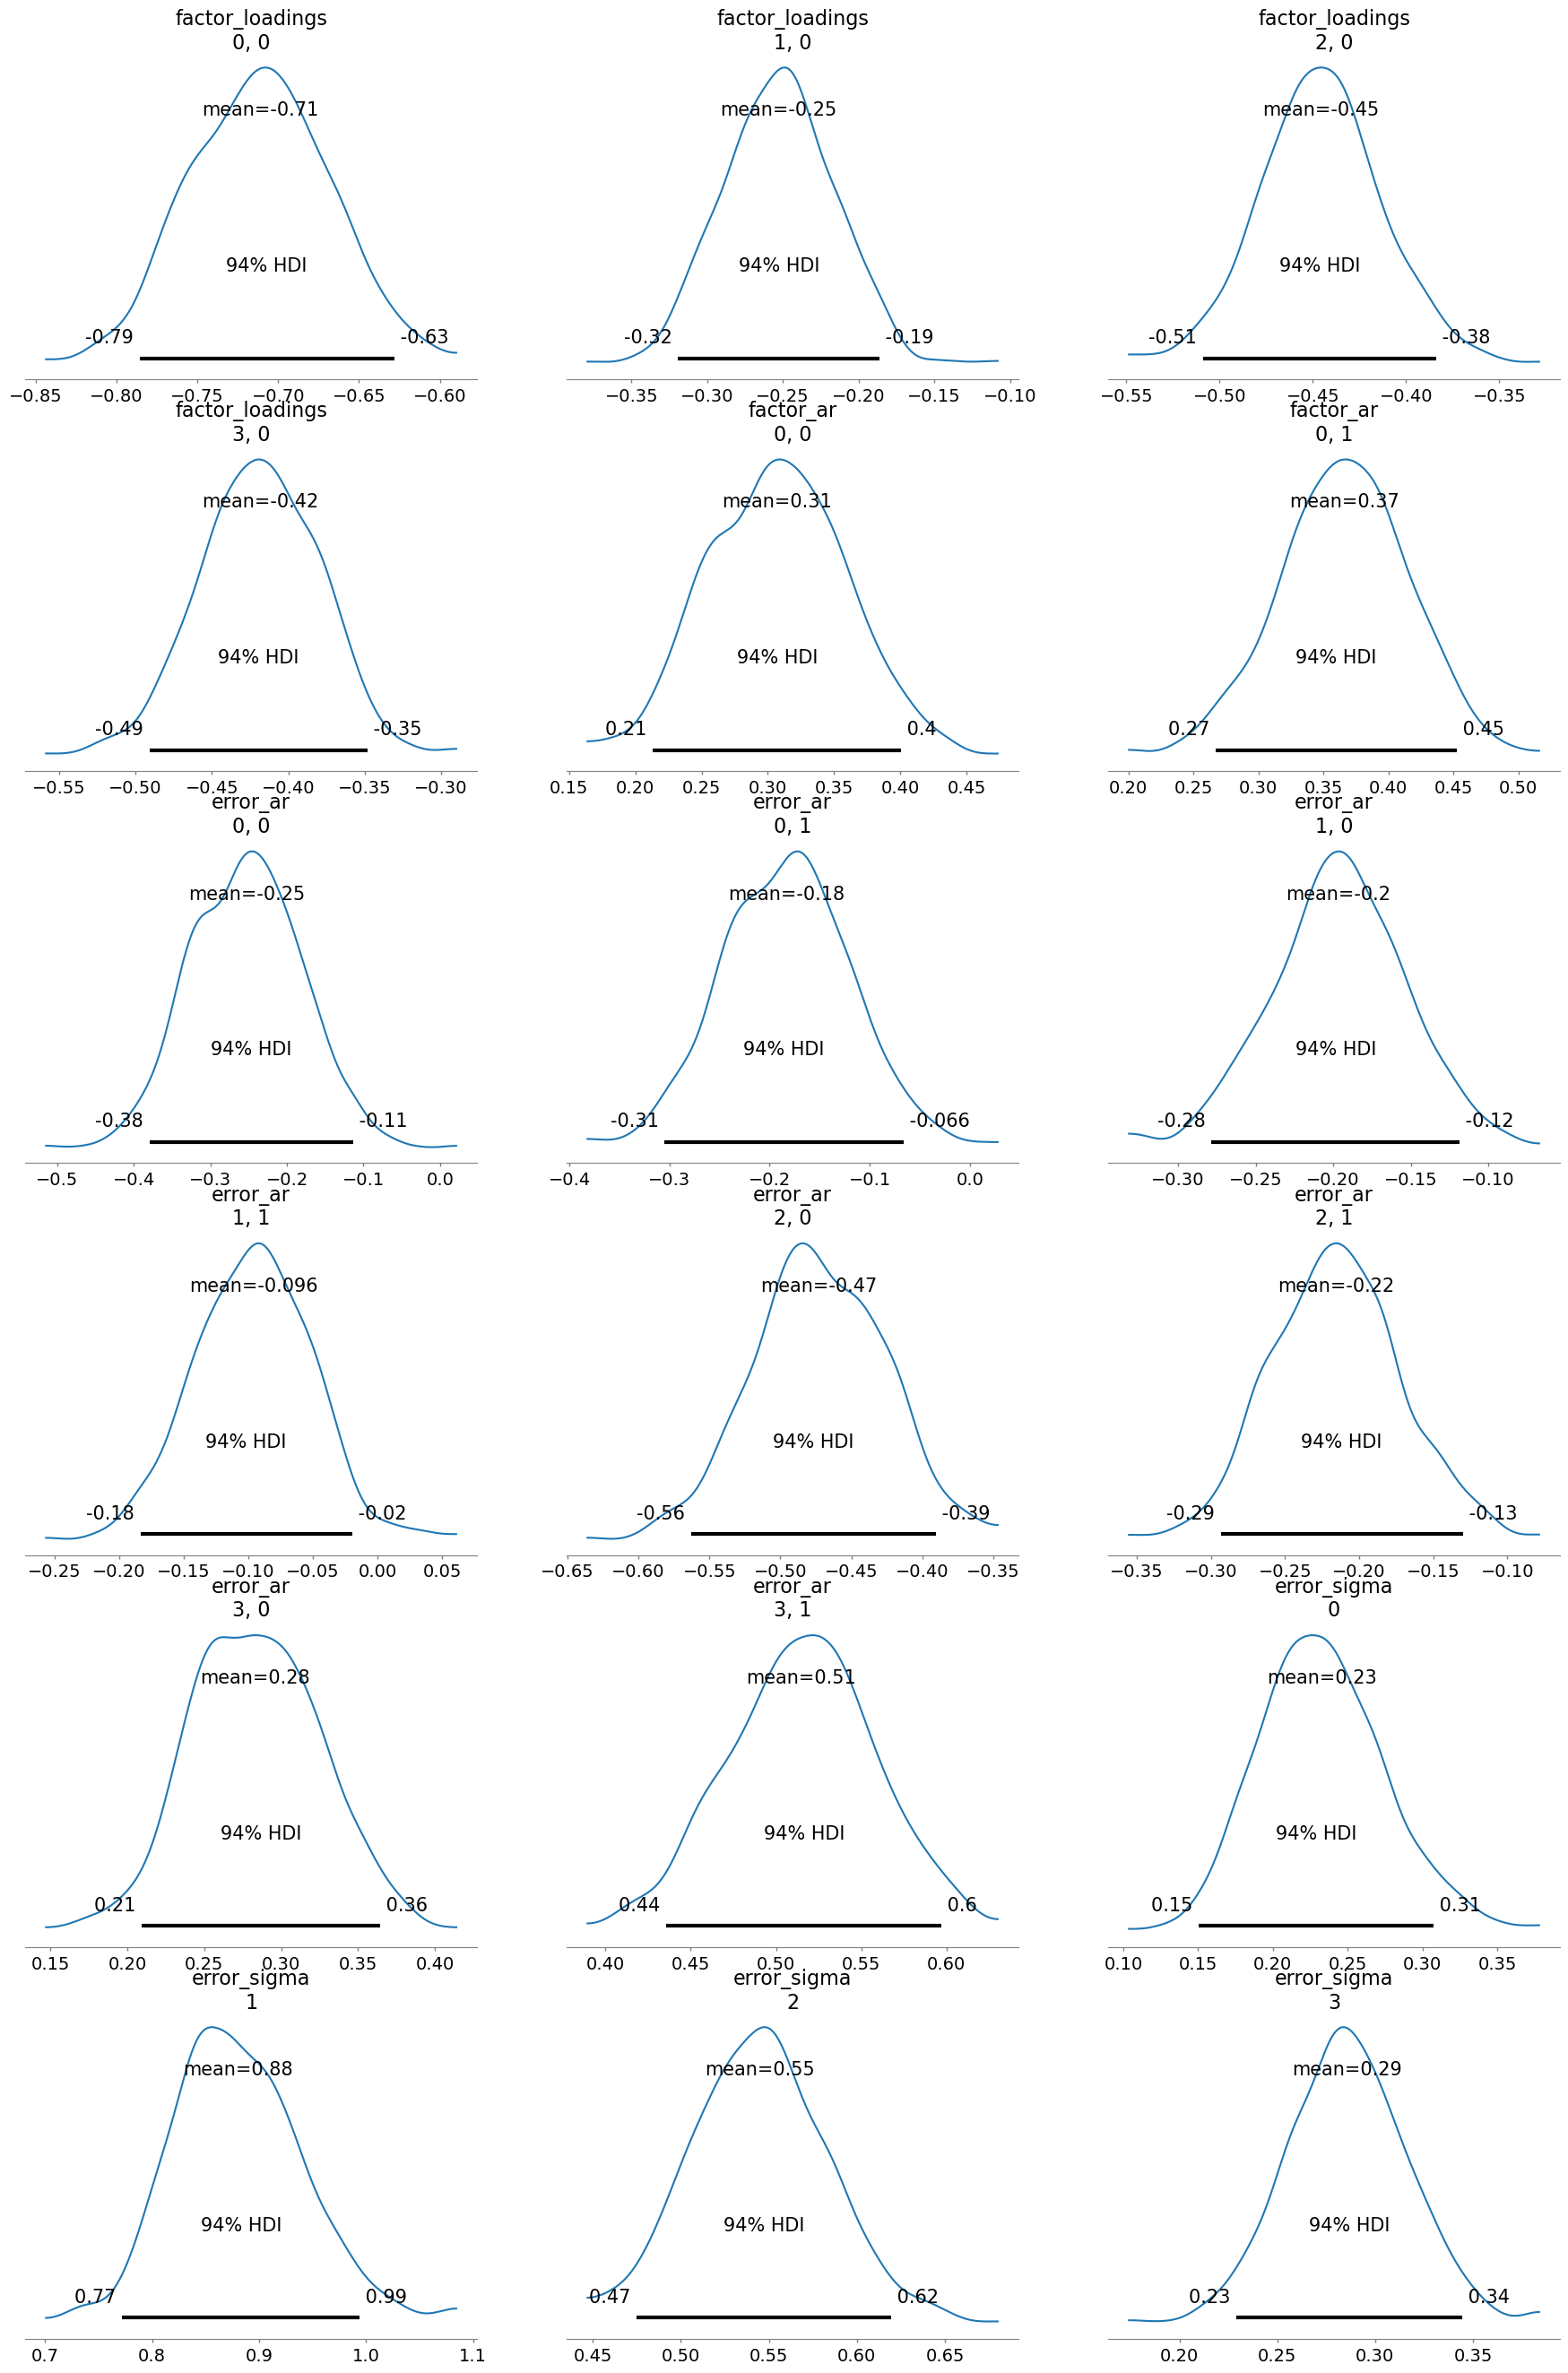

In [58]:
az.plot_posterior(
    idata_dfm_py,
    var_names=var_names_list_dfm_py  
);

In [50]:
with pm.Model() as index_mod:
    dfm._build_dummy_graph()
    dfm._insert_random_variables()
    x0, P0, C, D, T, Z, R, H, Q = matrices = dfm.unpack_statespace()

    dfm.build_statespace_graph(data=endog, mode="JAX", save_kalman_filter_outputs_in_idata=True)
    predicted_covariance = index_mod["predicted_covariance"]
    filtered_state = index_mod["filtered_state"]

    def step(P, Z, T, H):
        PZT = pt.dot(P, Z.T)
        F = Z.dot(PZT) + H + pt.eye(H.shape[0]) * 1e-6

        # K = pt.linalg.solve(F, pt.dot(T, PZT).T, assume_a="pos", check_finite=False).T   
        K = pt.linalg.solve(F, PZT.T, assume_a="pos", check_finite=False).T
        return K

    ss_kalman_gain, updates = pytensor.scan(step, non_sequences=[Z, T, H], 
                                           sequences=[predicted_covariance])
    
    ss_kalman_gain = ss_kalman_gain[-1] # Get the last Kalman gain (steady state)

    k_states = T.shape[0]
    W1 = pt.linalg.inv(
        pt.eye(k_states)
        - pt.dot(pt.eye(k_states) - pt.dot(ss_kalman_gain, Z), T)
    ).dot(ss_kalman_gain)[0]

    # Compute the factor mean vector
    factor_mean = pt.dot(W1, data.loc[start:, "dln_indprod":"dln_emp"].mean())

    state_0 = filtered_state[..., 0]

    # Normalization
    normalizer = np.std(usphci.diff()[1:]) / pt.std(state_0)
    state_0_scaled = state_0 * normalizer

    # Initial value (scalar)
    initial_value = usphci.iloc[0] * factor_mean / dusphci.mean()

    # Increments: each increment is state[t] + factor_mean (broadcasted)
    increments = state_0_scaled + factor_mean  # shape: (T,)

    # Cumulative sum of increments
    cumsum_increments = pt.cumsum(increments)
    coincident_index = pt.concatenate([[initial_value], initial_value + cumsum_increments])

    # Normalize to match USPHCI base year (e.g., July 1992)
    ref_idx = list(data.index).index(pd.Timestamp("1992-07-01"))
    base_value = usphci.loc["1992-07-01"]
    normalization_factor = base_value / coincident_index[ref_idx]
    coincident_index = coincident_index * normalization_factor

    pm.Deterministic("factor_mean", factor_mean)

    factor_mean_idata_dfm_py=pm.sample_posterior_predictive(idata_dfm_py, var_names=["factor_mean"])
    filtered_state_idata_dfm_py = pm.sample_posterior_predictive(idata_dfm_py, var_names=["filtered_state"])

    pm.Deterministic("coincident_index", coincident_index)
    coincident_index_idata_dfm_py = pm.sample_posterior_predictive(idata_dfm_py, var_names=["coincident_index"])


Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

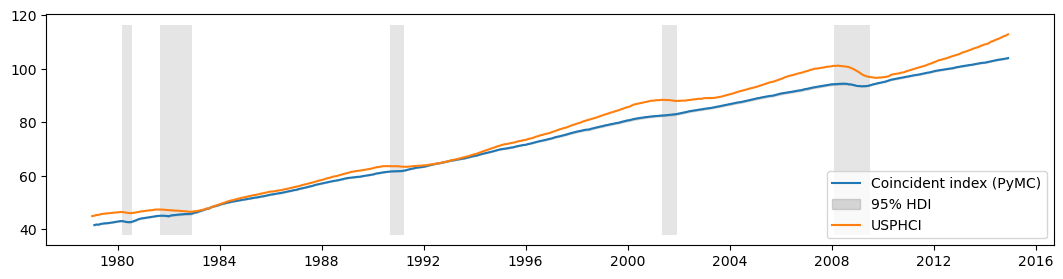

In [51]:
fig, ax = plt.subplots(figsize=(13, 3))

# Compute the index
coincident_index_pymc_samples_dfm_py = coincident_index_idata_dfm_py.posterior_predictive["coincident_index"].values
coincident_index_pymc_dfm_py = coincident_index_pymc_samples_dfm_py.mean(axis=(0, 1))


hdi_index_dfm_py = az.hdi(coincident_index_pymc_samples_dfm_py, hdi_prob=0.95)  
lower_index_dfm_py, upper_index_dfm_py = hdi_index_dfm_py[..., 0], hdi_index_dfm_py[..., 1]    

# Plot the factor
dates = endog.index._mpl_repr()
ax.plot(dates, coincident_index_pymc_dfm_py[1:], label="Coincident index (PyMC)")
ax.fill_between(dates, lower_index_dfm_py[1:], upper_index_dfm_py[1:], color='gray', alpha=0.3, label="95% HDI")
ax.plot(usphci.index._mpl_repr(), usphci, label="USPHCI")
ax.legend(loc="lower right")

# Retrieve and also plot the NBER recession indicators
ylim = ax.get_ylim()
ax.fill_between(
    dates[:-3], ylim[0], ylim[1], rec.values[:-4, 0], facecolor="k", alpha=0.1
);

In [52]:
# Extract posterior predictive samples
state_samples_dfm_py = filtered_state_idata_dfm_py.posterior_predictive["filtered_state"].values  # shape: (2, 500, 10, 431)

# Select the first state (index 0)
state_0_samples_dfm_py = state_samples_dfm_py[:, :, :, 0]  # shape: (1, 1000, 431)

# Average over chains and draws to get posterior mean for each time point
state_0_mean_dfm_py = state_0_samples_dfm_py.mean(axis=(0, 1))  # shape: (431,)

# Get the time index from your observed data for x-axis
dates = filtered_state_idata_dfm_py.observed_data.time.values  # array of datetime64


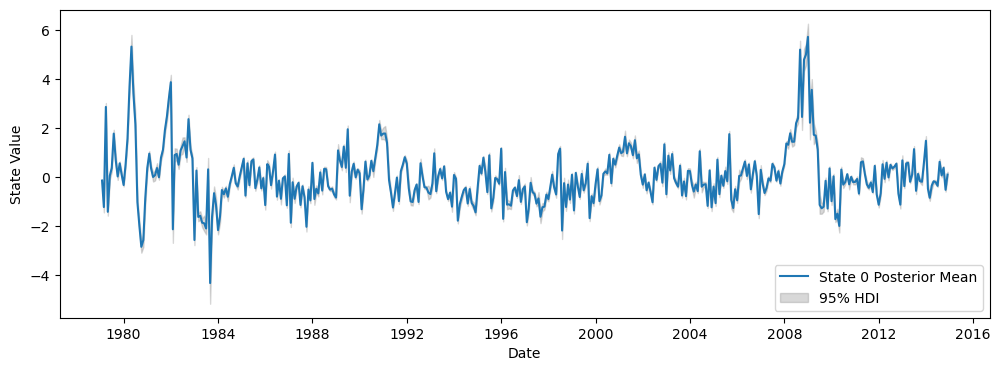

In [53]:
hdi_state_dfm_py = az.hdi(state_0_samples_dfm_py, hdi_prob=0.95)  
lower_state_dfm_py, upper_state_dfm_py = hdi_state_dfm_py[..., 0], hdi_state_dfm_py[..., 1]    

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dates, state_0_mean_dfm_py, label="State 0 Posterior Mean")
ax.fill_between(dates, lower_state_dfm_py, upper_state_dfm_py, color='gray', alpha=0.3, label="95% HDI")
ax.set_xlabel("Date")
ax.set_ylabel("State Value")
ax.legend()
plt.show()

## Comparison of PyMC (Dummy and using DFM.py) and Stats

In [12]:
res.params

loading.f1.std_indprod             -0.700627
loading.f1.std_income              -0.253440
loading.f1.std_sales               -0.437928
loading.f1.std_emp                 -0.427329
sigma2.std_indprod                  0.244496
sigma2.std_income                   0.875069
sigma2.std_sales                    0.556662
sigma2.std_emp                      0.277861
L1.f1.f1                            0.305439
L2.f1.f1                            0.365629
L1.e(std_indprod).e(std_indprod)   -0.260057
L2.e(std_indprod).e(std_indprod)   -0.188659
L1.e(std_income).e(std_income)     -0.197813
L2.e(std_income).e(std_income)     -0.097170
L1.e(std_sales).e(std_sales)       -0.464015
L2.e(std_sales).e(std_sales)       -0.211790
L1.e(std_emp).e(std_emp)            0.372574
L2.e(std_emp).e(std_emp)            0.618861
dtype: float64

In [64]:
az.summary(idata_custom, var_names=var_names_list_custom)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
ar[0],0.305,0.050,0.216,0.397,0.001,0.001,1246.0,905.0,1.00
ar[1],0.367,0.049,0.274,0.460,0.001,0.001,1375.0,817.0,1.00
lambdas[0],-0.715,0.042,-0.791,-0.636,0.001,0.001,830.0,686.0,1.00
lambdas[1],-0.254,0.037,-0.322,-0.182,0.001,0.001,1849.0,916.0,1.01
lambdas[2],-0.446,0.032,-0.505,-0.385,0.001,0.001,990.0,651.0,1.00
lambdas[3],-0.417,0.038,-0.495,-0.351,0.001,0.001,989.0,769.0,1.00
"c[0, 0]",-0.255,0.072,-0.392,-0.131,0.001,0.002,2613.0,884.0,1.00
"c[0, 1]",-0.187,0.065,-0.305,-0.074,0.002,0.002,1256.0,959.0,1.00
"c[1, 0]",-0.198,0.042,-0.273,-0.119,0.001,0.002,1798.0,755.0,1.01
"c[1, 1]",-0.095,0.044,-0.178,-0.017,0.001,0.001,2461.0,868.0,1.00


In [65]:
az.summary(idata_dfm_py, var_names=var_names_list_dfm_py)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"factor_loadings[0, 0]",-0.711,0.043,-0.786,-0.628,0.002,0.001,811.0,596.0,1.00
"factor_loadings[1, 0]",-0.253,0.037,-0.319,-0.186,0.001,0.002,3000.0,724.0,1.01
"factor_loadings[2, 0]",-0.446,0.033,-0.509,-0.384,0.001,0.001,1004.0,663.0,1.00
"factor_loadings[3, 0]",-0.419,0.040,-0.491,-0.348,0.001,0.001,907.0,526.0,1.00
"factor_ar[0, 0]",0.307,0.052,0.213,0.401,0.001,0.001,1229.0,734.0,1.00
"factor_ar[0, 1]",0.366,0.050,0.267,0.453,0.001,0.001,1353.0,901.0,1.00
"error_ar[0, 0]",-0.253,0.072,-0.379,-0.113,0.002,0.002,1825.0,913.0,1.00
"error_ar[0, 1]",-0.183,0.064,-0.305,-0.066,0.002,0.002,1493.0,792.0,1.00
"error_ar[1, 0]",-0.197,0.043,-0.279,-0.118,0.001,0.001,1919.0,746.0,1.00
"error_ar[1, 1]",-0.096,0.045,-0.184,-0.020,0.001,0.002,2168.0,657.0,1.01


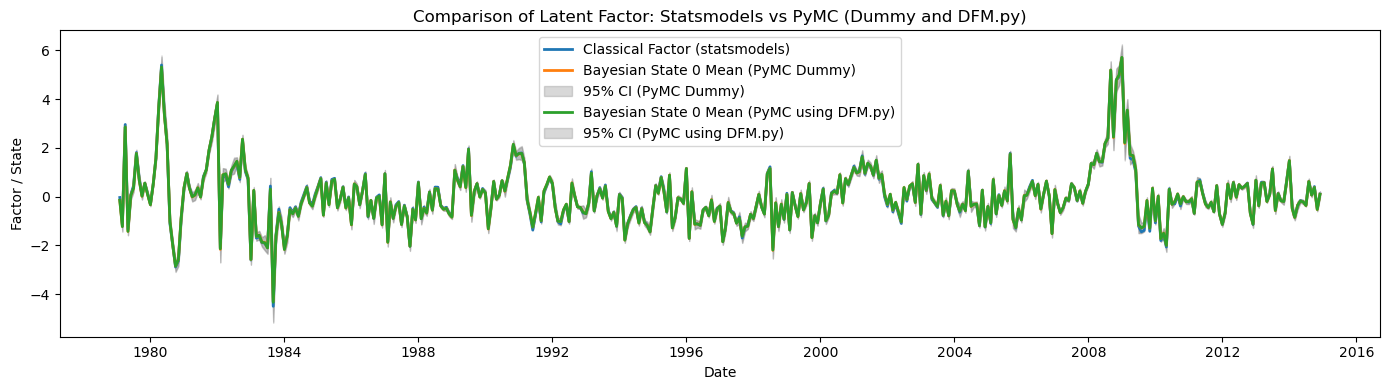

In [66]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dates, res.factors.filtered[0], label="Classical Factor (statsmodels)", linewidth=2)
ax.plot(dates, state_0_mean_custom, label="Bayesian State 0 Mean (PyMC Dummy)", linewidth=2)
ax.fill_between(dates, lower_state_custom, upper_state_custom, color='gray', alpha=0.3, label="95% CI (PyMC Dummy)")
ax.plot(dates, state_0_mean_dfm_py, label="Bayesian State 0 Mean (PyMC using DFM.py)", linewidth=2)
ax.fill_between(dates, lower_state_dfm_py, upper_state_dfm_py, color='gray', alpha=0.3, label="95% CI (PyMC using DFM.py)")
ax.legend()
ax.set_title("Comparison of Latent Factor: Statsmodels vs PyMC (Dummy and DFM.py)")
ax.set_xlabel("Date")
ax.set_ylabel("Factor / State")
plt.tight_layout()
plt.show()

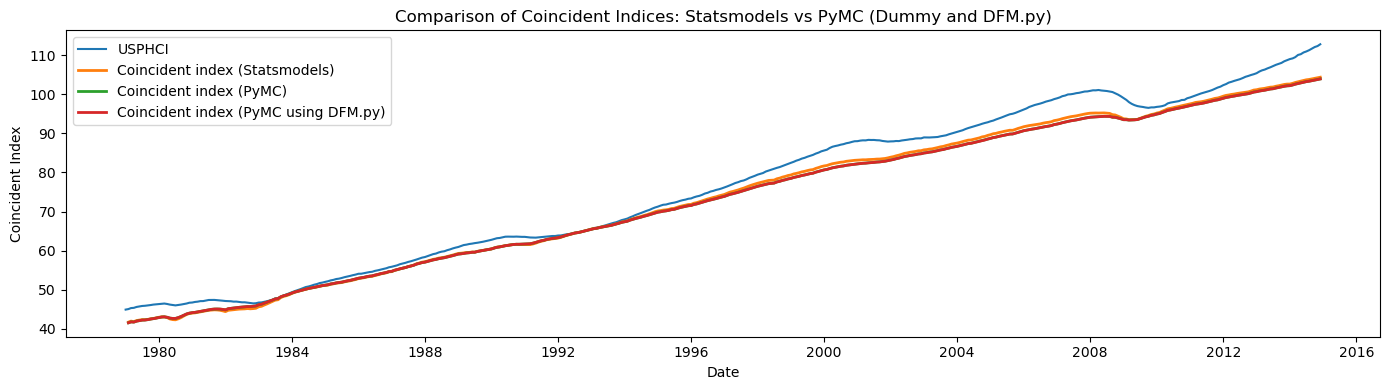

In [67]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(usphci.index._mpl_repr(), usphci, label="USPHCI")
ax.plot(dates, coincident_index_res, label="Coincident index (Statsmodels)", linewidth=2)
ax.plot(dates, coincident_index_pymc_custom[1:], label="Coincident index (PyMC)", linewidth=2)
ax.plot(dates, coincident_index_pymc_dfm_py[1:], label="Coincident index (PyMC using DFM.py)", linewidth=2)
ax.legend()
ax.set_title("Comparison of Coincident Indices: Statsmodels vs PyMC (Dummy and DFM.py)")
ax.set_xlabel("Date")
ax.set_ylabel("Coincident Index")
plt.tight_layout()
plt.show()